# CH 6 — Is Data Mining Based on a Sound Premise? A Qualified Yes

## Objectif pédagogique

Ce notebook transforme l’idée d’Aronson en simulation Python simple.

La question centrale est :

> Est-ce que chercher la meilleure règle parmi des centaines ou des milliers de règles est une méthode rationnelle, ou seulement une machine à produire des illusions statistiques ?

La réponse est :

> **Oui, le minage de données peut être rationnel, mais seulement sous condition : il faut assez d’observations pour séparer le mérite réel du bruit.**

Dans ce notebook, on va voir pourquoi avec une simulation contrôlée.

## 1. Le problème EBTA

En trading algorithmique, on teste souvent plusieurs règles :

- une règle RSI ;
- une règle moyenne mobile ;
- une règle breakout ;
- une règle VWAP ;
- des centaines de variantes de paramètres.

Le danger est simple : plus on teste de règles, plus on augmente la probabilité de trouver une règle qui semble excellente **par chance**.

Mais Aronson nuance cette critique.

Le minage de données ne sert pas forcément à prédire directement le profit futur exact.

Il peut servir à **classer** les règles.

Autrement dit :

> Même si le meilleur backtest exagère souvent le profit futur, il peut quand même pointer vers une règle qui possède plus de mérite réel que les autres.

## 2. Le modèle mental

On peut décomposer la performance observée d’une règle ainsi :

$$
P_{\text{observée}} = P_{\text{mérite réel}} + H
$$

où :

- $P_{\text{observée}}$ est la performance mesurée dans le **backtest** ;
- $P_{\text{mérite réel}}$ est l’espérance réelle de la règle ;
- $H$ est le hasard, le bruit, ou l’erreur d’échantillonnage.

Le minage de données choisit la règle avec le plus grand $P_{\text{observée}}$.

Le problème est donc :

$$
\text{Règle gagnante} = \arg\max(P_{\text{mérite réel}} + H)
$$

Si $H$ domine, le gagnant est choisi au hasard.

Si $P_{\text{mérite réel}}$ domine, le gagnant est probablement une vraie bonne règle.

## 3. Expérience pédagogique

On va créer un univers artificiel de règles de trading.

Chaque règle possède un **mérite réel** inconnu du chercheur.

Ensuite, on simule un backtest avec $N$ observations.

Plus $N$ est grand, plus la moyenne observée devient fiable.

Nous allons mesurer trois choses :

| Élément | Signification |
|---|---|
| **performance observée du gagnant** | Ce que le backtest montre |
| **mérite réel du gagnant** | Ce que la règle vaut vraiment |
| **probabilité de choisir la vraie meilleure règle** | Qualité du classement |

L’idée clé :

> Si $N$ est trop faible, le gagnant du backtest est souvent seulement le plus chanceux.  
> Si $N$ est élevé, le gagnant du backtest se rapproche de la vraie meilleure règle.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

## 4. Fonction de simulation

On définit une fonction qui simule une compétition entre plusieurs règles.

Chaque règle a un mérite réel tiré autour d’une moyenne.

Ensuite, chaque règle produit $N$ rendements observés.

La règle sélectionnée est celle qui affiche la meilleure moyenne de backtest.

In [2]:
def simulate_data_mining_competition(
    n_rules=100,
    n_observations=100,
    true_mean=0.001,
    true_merit_std=0.002,
    noise_std=0.03,
    n_trials=1000
):
    """
    Simule une compétition de data mining entre plusieurs règles.

    Paramètres
    ----------
    n_rules : int
        Nombre de règles testées.
    n_observations : int
        Nombre d'observations utilisées pour calculer la performance.
    true_mean : float
        Mérite moyen réel des règles.
    true_merit_std : float
        Dispersion des mérites réels entre les règles.
    noise_std : float
        Bruit des rendements observés.
    n_trials : int
        Nombre de compétitions simulées.

    Retour
    ------
    pd.DataFrame
        Résultats de chaque compétition simulée.
    """

    results = []

    for _ in range(n_trials):
        # Mérite réel de chaque règle
        true_merits = np.random.normal(
            loc=true_mean,
            scale=true_merit_std,
            size=n_rules
        )

        # Rendements simulés : mérite réel + bruit
        returns = np.random.normal(
            loc=true_merits[:, None],
            scale=noise_std,
            size=(n_rules, n_observations)
        )

        observed_means = returns.mean(axis=1)

        selected_rule = np.argmax(observed_means)
        true_best_rule = np.argmax(true_merits)

        results.append({
            "n_rules": n_rules,
            "n_observations": n_observations,
            "selected_observed_mean": observed_means[selected_rule],
            "selected_true_merit": true_merits[selected_rule],
            "true_best_merit": true_merits[true_best_rule],
            "selected_is_true_best": selected_rule == true_best_rule,
            "rank_error": true_merits[true_best_rule] - true_merits[selected_rule]
        })

    return pd.DataFrame(results)

## 5. Premier test : peu d’observations contre beaucoup d’observations

On compare trois situations :

| Situation | Interprétation |
|---|---|
| $N = 2$ | Backtest quasi inutile |
| $N = 100$ | Backtest modérément informatif |
| $N = 1000$ | Backtest beaucoup plus fiable |

On garde le même nombre de règles testées : 256.

In [3]:
experiments = []

for n_obs in [2, 100, 1000]:
    df = simulate_data_mining_competition(
        n_rules=256,
        n_observations=n_obs,
        true_mean=0.001,
        true_merit_std=0.002,
        noise_std=0.03,
        n_trials=2000
    )
    experiments.append(df)

comparison = pd.concat(experiments, ignore_index=True)

summary = comparison.groupby("n_observations").agg(
    avg_observed_mean_of_winner=("selected_observed_mean", "mean"),
    avg_true_merit_of_winner=("selected_true_merit", "mean"),
    avg_true_best_merit=("true_best_merit", "mean"),
    probability_select_true_best=("selected_is_true_best", "mean"),
    avg_rank_error=("rank_error", "mean")
)

summary

,avg_observed_mean_of_winner,avg_true_merit_of_winner,avg_true_best_merit,probability_select_true_best,avg_rank_error
n_observations,,,,,
2,0.061189,0.001564,0.006658,0.0055,0.005094
100,0.011170,0.004183,0.006650,0.0950,0.002467
1000,0.007262,0.006115,0.006648,0.4385,0.000534


## 6. Lecture du tableau

La colonne la plus importante est :

$$
\text{avg true merit of winner}
$$

Elle répond à la question :

> Quand je sélectionne le meilleur backtest, quelle est la vraie qualité moyenne de la règle que je sélectionne ?

La deuxième colonne importante est :

$$
\text{probability select true best}
$$

Elle répond à la question :

> Quelle est la probabilité que le gagnant du backtest soit vraiment la meilleure règle de l’univers testé ?

Ce que l’on doit observer :

- avec $N = 2$, la probabilité de choisir la vraie meilleure règle est très faible ;
- avec $N = 100$, le classement s’améliore ;
- avec $N = 1000$, le minage devient beaucoup plus rationnel.

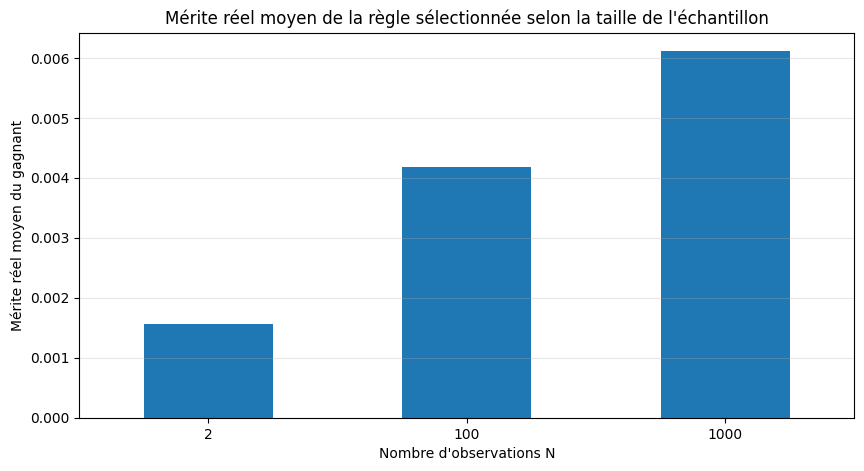

In [4]:
plt.figure(figsize=(10, 5))
summary["avg_true_merit_of_winner"].plot(kind="bar")
plt.title("Mérite réel moyen de la règle sélectionnée selon la taille de l'échantillon")
plt.xlabel("Nombre d'observations N")
plt.ylabel("Mérite réel moyen du gagnant")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

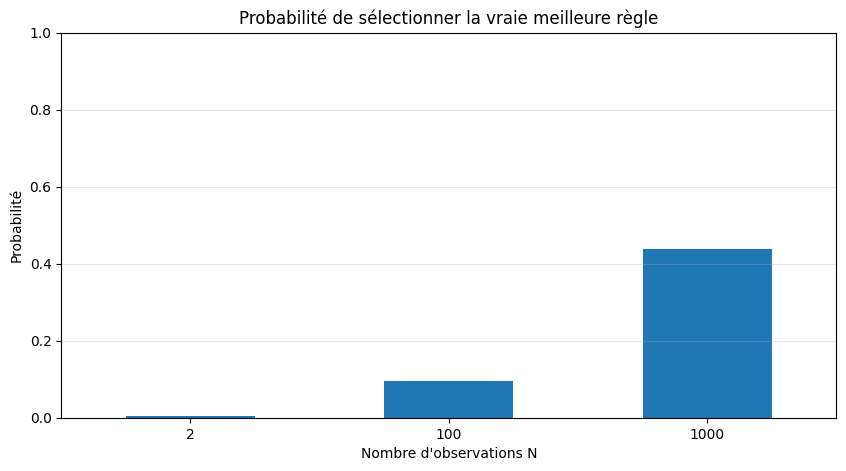

In [5]:
plt.figure(figsize=(10, 5))
summary["probability_select_true_best"].plot(kind="bar")
plt.title("Probabilité de sélectionner la vraie meilleure règle")
plt.xlabel("Nombre d'observations N")
plt.ylabel("Probabilité")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.show()

## 7. Pourquoi le gagnant du backtest peut mentir

Même quand le minage aide à sélectionner une meilleure règle, il reste un problème :

> La performance observée du gagnant est souvent exagérée.

C’est le **biais de minage de données**.

Le gagnant n’est pas seulement sélectionné parce qu’il a du mérite.

Il est aussi sélectionné parce qu’il a bénéficié d’un bruit favorable.

On peut mesurer cette inflation ainsi :

$$
\text{biais} = P_{\text{observée du gagnant}} - P_{\text{mérite réel du gagnant}}
$$

In [6]:
comparison["data_mining_bias"] = (
    comparison["selected_observed_mean"] - comparison["selected_true_merit"]
)

bias_summary = comparison.groupby("n_observations").agg(
    avg_observed_mean_of_winner=("selected_observed_mean", "mean"),
    avg_true_merit_of_winner=("selected_true_merit", "mean"),
    avg_data_mining_bias=("data_mining_bias", "mean")
)

bias_summary

,avg_observed_mean_of_winner,avg_true_merit_of_winner,avg_data_mining_bias
n_observations,,,
2,0.061189,0.001564,0.059625
100,0.011170,0.004183,0.006987
1000,0.007262,0.006115,0.001147


<Figure size 1000x500 with 0 Axes>

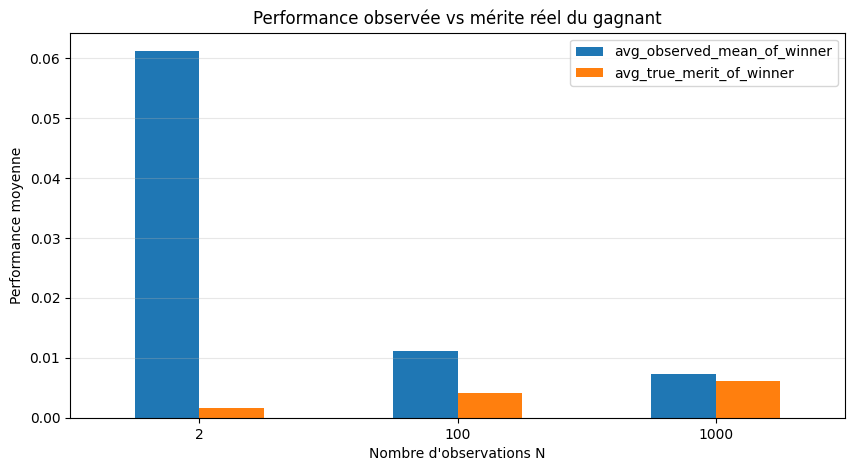

In [7]:
plt.figure(figsize=(10, 5))
bias_summary[["avg_observed_mean_of_winner", "avg_true_merit_of_winner"]].plot(kind="bar", figsize=(10, 5))
plt.title("Performance observée vs mérite réel du gagnant")
plt.xlabel("Nombre d'observations N")
plt.ylabel("Performance moyenne")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

## 8. Deux vérités en même temps

Cette section est importante car elle évite deux erreurs opposées.

### Erreur 1 : rejeter totalement le minage de données

Ce serait dire :

> Tester beaucoup de règles ne produit que des illusions.

Ce n’est pas toujours vrai.

Si l’échantillon est grand, le minage peut aider à découvrir une règle réellement supérieure.

### Erreur 2 : croire naïvement le meilleur backtest

Ce serait dire :

> La meilleure règle du passé sera aussi bonne dans le futur.

C’est faux.

Même si la règle sélectionnée a du mérite, son score historique est probablement gonflé par la chance.

La bonne lecture EBTA est donc :

> Le minage de données peut être utile pour **classer** les règles, mais il faut corriger l’illusion sur le **niveau de performance**.

## 9. Effet du nombre de règles testées

Aronson explique aussi que, si l’échantillon est suffisant, tester plus de règles augmente les chances de trouver une règle de haut mérite.

Mais si l’échantillon est trop petit, tester plus de règles ne fait qu’augmenter le bruit sélectionné.

On va comparer plusieurs tailles d’univers :

$$
K \in \{2, 4, 8, 16, 32, 64, 128, 256\}
$$

où $K$ est le nombre de règles testées.

In [8]:
def run_grid_over_rules(n_observations, rule_counts, n_trials=1000):
    frames = []

    for k in rule_counts:
        df = simulate_data_mining_competition(
            n_rules=k,
            n_observations=n_observations,
            true_mean=0.001,
            true_merit_std=0.002,
            noise_std=0.03,
            n_trials=n_trials
        )
        frames.append(df)

    return pd.concat(frames, ignore_index=True)


rule_counts = [2, 4, 8, 16, 32, 64, 128, 256]

grid_low_n = run_grid_over_rules(n_observations=2, rule_counts=rule_counts, n_trials=1500)
grid_high_n = run_grid_over_rules(n_observations=1000, rule_counts=rule_counts, n_trials=1500)

grid = pd.concat([
    grid_low_n.assign(scenario="N = 2"),
    grid_high_n.assign(scenario="N = 1000")
])

grid_summary = grid.groupby(["scenario", "n_rules"]).agg(
    avg_true_merit_of_winner=("selected_true_merit", "mean"),
    avg_observed_mean_of_winner=("selected_observed_mean", "mean")
).reset_index()

grid_summary.head()

,scenario,n_rules,avg_true_merit_of_winner,avg_observed_mean_of_winner
0,N = 1000,2,0.002051,0.002261
1,N = 1000,4,0.002908,0.003301
2,N = 1000,8,0.003566,0.004101
3,N = 1000,16,0.004168,0.004894
4,N = 1000,32,0.004750,0.005598


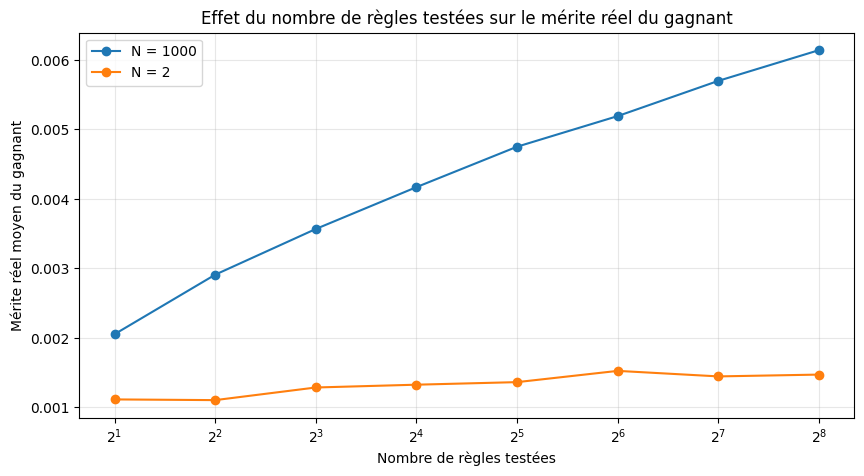

In [9]:
plt.figure(figsize=(10, 5))

for scenario, data in grid_summary.groupby("scenario"):
    plt.plot(
        data["n_rules"],
        data["avg_true_merit_of_winner"],
        marker="o",
        label=scenario
    )

plt.title("Effet du nombre de règles testées sur le mérite réel du gagnant")
plt.xlabel("Nombre de règles testées")
plt.ylabel("Mérite réel moyen du gagnant")
plt.xscale("log", base=2)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 10. Interprétation trading

Le graphique montre l’idée centrale :

- si $N$ est faible, tester plus de règles ne permet pas vraiment de sélectionner plus de mérite réel ;
- si $N$ est élevé, tester plus de règles augmente la qualité réelle moyenne du gagnant.

C’est exactement la logique du **qualified yes**.

Le minage de données est valide, mais pas gratuitement.

Il faut payer avec :

- plus d’observations ;
- une procédure statistique robuste ;
- une validation hors-échantillon ;
- une correction du biais de sélection ;
- une discipline contre l’overfitting.

> L’ordinateur peut être un excellent recruteur de règles, mais seulement si chaque candidate passe assez d’épreuves.

## 11. Application EBTA à ton propre trading

Pour un trader systématique, cette section donne une règle opérationnelle très claire.

### Cas dangereux

Tu testes 200 variantes d’une stratégie sur 3 mois de données.

Le meilleur résultat sort avec une equity curve magnifique.

Mais le problème est :

$$
H \gg P_{\text{mérite réel}}
$$

Le hasard domine le mérite.

La règle gagnante est probablement une illusion.

### Cas plus défendable

Tu testes 200 variantes sur plusieurs années de données propres, avec assez de trades, puis tu confirmes hors-échantillon.

Ici, le bruit existe encore, mais il est moins dominant.

Le classement devient plus informatif.

### Traduction pratique

| Situation | Lecture EBTA |
|---|---|
| Peu de données + beaucoup de règles | danger extrême d’overfitting |
| Beaucoup de données + peu de règles | test plus fiable, mais exploration limitée |
| Beaucoup de données + beaucoup de règles | data mining potentiellement utile |
| Meilleur backtest sans correction | performance probablement gonflée |
| Meilleur backtest + validation OOS | candidat plus sérieux |

## 12. Checklist de décision

Avant d’accepter une règle issue d’un processus de minage, pose ces questions :

- Ai-je assez d’observations ?
- Ai-je assez de trades réels, pas seulement assez de bougies ?
- Le gagnant dépasse-t-il largement la moyenne des règles testées ?
- La performance reste-t-elle stable sur plusieurs périodes ?
- Ai-je testé hors-échantillon ?
- Ai-je corrigé le biais lié au nombre de règles testées ?
- La règle est-elle logique économiquement ou seulement jolie statistiquement ?

> Une règle minée n’est pas une preuve.  
> C’est un candidat qui doit encore survivre à l’inférence statistique.

## 13. L’Eurêka final

> **Le data mining n’est pas le problème. Le problème, c’est de miner trop de règles avec trop peu de données, puis de croire naïvement le meilleur score.**

La position d’Aronson est subtile :

- le minage de données peut identifier les meilleures règles ;
- mais seulement si l’échantillon est assez grand ;
- et même dans ce cas, la performance du gagnant doit être traitée comme gonflée ;
- donc le minage doit être accompagné d’une méthode d’inférence sérieuse.

En langage de trader :

> Le backtest gagnant te montre où regarder.  
> Il ne te donne pas encore la permission de risquer du capital.

## 14. Résumé ultra-court

| Idée | Conclusion |
|---|---|
| Tester beaucoup de règles | Peut être utile |
| Tester beaucoup de règles sur peu de données | Très dangereux |
| Grand échantillon | Améliore le classement |
| Petit échantillon | Le bruit domine |
| Meilleur backtest | Souvent biaisé |
| Mérite réel | Se détecte mieux quand $N$ augmente |

> **Le nombre d’observations est le filtre qui transforme le data mining d’une loterie en méthode de recherche.**

## Annexe — Source originale

### **CH 6 : IS DATA MINING BASED ON A SOUND PREMISE? — A QUALIFIED YES!**

Voici l’analyse technique de la section traitant de la validité fondamentale du minage de données en tant que méthode de recherche. David Aronson y répond à la question : « Est-ce que chercher la meilleure règle parmi des milliers a un sens ? »

#### **(AJOUT) Idées clés :**
*   **Validation du classement :** Le minage de données est efficace pour identifier la règle ayant le meilleur potentiel futur, à condition que l'échantillon soit large,.
*   **La preuve de White :** Mathématiquement, la probabilité de sélectionner la "véritable" meilleure règle parmi un ensemble tend vers 100 % à mesure que le nombre d'observations augmente,.
*   **La condition critique :** Sans un nombre suffisant d'observations, le minage de données échoue totalement et ne produit rien de mieux qu'un choix au hasard,.
*   **Gain d'intensité :** Plus on teste de règles sur un échantillon large, plus on a de chances de découvrir une règle de haut mérite,.

#### **Référence :**
*Is Data Mining Based on a Sound Premise?—A Qualified Yes!*, Chapitre 6, pages 309 à 311.

#### **Citation Directe :**
« Fortunately for the field of data mining, the answer to both questions is a qualified yes. The qualification relates to the number of observations that are used to compute the rule’s mean return or other performance statistics. » (Page 309).

---

#### **Vision Macro :**
L'enjeu est de légitimer l'utilisation de la puissance de calcul en trading. David Aronson explique que le minage de données n'est pas une simple "chasse aux fantômes" statistique, mais une procédure de sélection rationnelle,. Cependant, cette légitimité est conditionnelle (« qualified ») : elle repose entièrement sur l'intégrité des données. Le but est de montrer que si l'ordinateur peut nous mentir sur le *montant* du profit futur (le biais), il est néanmoins une excellente boussole pour nous diriger vers les règles qui possèdent un réel pouvoir prédictif,.

---

#### **Vision Micro :**
Le mécanisme de cette "efficacité qualifiée" repose sur deux démonstrations :

1.  **La Preuve de Convergence de White :** Halbert White a prouvé que si la taille de l'échantillon tend vers l'infini, la règle affichant la meilleure performance passée sera obligatoirement celle ayant la meilleure espérance de gain réelle,. Cela valide le principe de sélection du maximum,.
2.  **L'Expérience 2 (Mérites Variables) :** 
    *   Dans un univers où le mérite moyen est de +1,4 % par an, Aronson a testé l'effet du nombre d'observations ($N$),.
    *   **Avec $N = 2$ mois :** La performance de la règle sélectionnée reste plate à +1,4 %. Tester 2 ou 256 règles ne change rien ; le hasard est trop fort pour que le talent soit détecté, .
    *   **Avec $N = 100$ ou $1000$ mois :** La courbe de mérite réel s'élève. Pour 256 règles testées sur 1 000 mois, le minage permet de trouver une règle dont le talent réel est de **+10 %**, prouvant que la recherche intensive paie,.
3.  **L'utilité du "N" élevé :** Si l'échantillon est vaste, tester plus de règles (passer de 10 à 250) augmente mathématiquement la probabilité de tomber sur une règle exceptionnelle,.

---

#### **(AJOUT) Résumé Simplifié :**
Le minage de données, c'est comme organiser une audition pour trouver un chanteur. Si vous ne les écoutez chanter qu'une seule note (échantillon faible), vous choisirez n'importe qui par erreur. Mais si vous les faites chanter pendant 10 concerts (échantillon large), vous finirez forcément par trouver le meilleur talent. Aronson nous dit : l'ordinateur est un excellent recruteur, mais seulement si vous lui donnez assez de temps pour juger chaque candidat, .

---

#### **Actions Concrètes :**
*   **Bannir l'optimisation sur échantillon court :** Si vous n'avez pas au moins plusieurs centaines de points de données, n'utilisez pas de fonctions d'optimisation ; le résultat sera purement aléatoire,.
*   **Augmenter le nombre de tests si les données le permettent :** Si vous avez accès à 30 ans de données quotidiennes, n'hésitez pas à tester un grand univers de règles ; votre capacité à trouver du "vrai or" augmente avec le nombre de tentatives,.
*   **Vérifier le mérite relatif :** Assurez-vous que le gagnant de votre minage surpasse largement la moyenne de l'univers testé, ce qui est un signe de détection de mérite réel,.

---

#### **(AJOUT) À retenir absolument :**
*   Le minage de données **fonctionne** pour choisir la meilleure règle,.
*   Le succès du minage dépend **entièrement de la taille de l'échantillon**,.
*   Sur peu de données, tester plus de règles n'apporte **aucun bénéfice**.
*   Sur beaucoup de données, plus vous cherchez, **plus vous trouvez de qualité**.
*   L'échantillon est le **filtre** qui sépare le talent du bruit, .

J'ai terminé l'analyse de la section sur la validité du minage de données selon le protocole EBTA.